# Driving School Management System
# Data Analysis Report
## Author: Mohammad Mahdi Sarwari

## This notebook analyzes data from the Driving School Management System database using Python, Pandas, and Matplotlib.

In [16]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


# Part 1: Database Connection
In this section, a connection is established between Python and the MySQL database.
This connection allows the notebook to retrieve and analyze data stored in the Driving School Management System database.

In [18]:
# Connection settings come from ../config.ini (or the defaults in db_config.py)
import sys
sys.path.insert(0, "..")
import db_config

mydb = db_config.connect()

print("Connected successfully")


Connected successfully


# Part 2: Loading Data from MySQL
The database tables are imported into Python as Pandas DataFrames.
This process allows us to manipulate, clean, and analyze the data efficiently.

In [ ]:
students = pd.read_sql("SELECT * FROM Student", mydb)
instructors = pd.read_sql("SELECT * FROM Instructor", mydb)
vehicles = pd.read_sql("SELECT * FROM Vehicle", mydb)
lessons = pd.read_sql("SELECT * FROM Lesson", mydb)
exams = pd.read_sql("SELECT * FROM Exam", mydb)
payments = pd.read_sql("SELECT * FROM Payment", mydb)
packages = pd.read_sql("SELECT * FROM Package", mydb)
student_packages = pd.read_sql("SELECT * FROM StudentPackage", mydb)

print("All tables loaded")

All tables loaded


C:\Users\SARWARI\AppData\Local\Temp\ipykernel_13876\999685213.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  students = pd.read_sql("SELECT * FROM Student", mydb)
C:\Users\SARWARI\AppData\Local\Temp\ipykernel_13876\999685213.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  instructors = pd.read_sql("SELECT * FROM Instructor", mydb)
C:\Users\SARWARI\AppData\Local\Temp\ipykernel_13876\999685213.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vehicles = pd.read_sql("SELECT * FROM Vehicle", mydb)
C:\Users\SARWARI\Ap

In [32]:
print("Students:", len(students))
print("Instructors:", len(instructors))
print("Vehicles:", len(vehicles))
print("Lessons:", len(lessons))
print("Exams:", len(exams))
print("Payments:", len(payments))
print("Packages:", len(packages))
print("Student Packages:", len(student_packages))

Students: 30
Instructors: 5
Vehicles: 4
Lessons: 100
Exams: 17
Payments: 30
Packages: 5
Student Packages: 30


## Interpretation
The dataset contains information about 30 students, 5 instructors, 100 lessons, 4 vehicles, 30 payments, 17 exams, 5 training packages and 30 packages choosed by students.

# Part 3: Data Cleaning
Data cleaning is performed to ensure consistency and accuracy.
The process includes:
- Converting dates into datetime format
- Converting numerical values into numeric format
- Removing duplicate records
- Handling possible invalid values

In [33]:
lessons["LessonDate"] = pd.to_datetime(
    lessons["LessonDate"],
    errors="coerce"
)

payments["PaymentDate"] = pd.to_datetime(
    payments["PaymentDate"],
    errors="coerce"
)

lessons["DurationHours"] = pd.to_numeric(
    lessons["DurationHours"],
    errors="coerce"
)

payments["Amount"] = pd.to_numeric(
    payments["Amount"],
    errors="coerce"
)

lessons = lessons.drop_duplicates()

print("Data cleaning completed")

Data cleaning completed


## Interpretation
Data cleaning improves data quality and reduces the risk of incorrect analysis.
The cleaned dataset provides a reliable foundation for further investigation and visualization.

# Part 4: Data Integration 
Multiple tables are combined into two dataset using common identifiers.

In [34]:
#Integration A
lesson_full = (
    lessons
    .merge(students, on="StudentID")
    .merge(instructors, on="InstructorID")
    .merge(vehicles, on="VehicleID")
)

lesson_full.head()

,LessonID,StudentID,InstructorID_x,VehicleID,LessonDate,DurationHours,FirstName,LastName,Phone_x,Email,RegistrationDate,InstructorName,Phone_y,HireDate,ExperienceYears,Model,PlateNumber,Year,InstructorID_y
0,1,8,1,1,2025-02-01,3,Maryam,Safari,3501000008,maryam.s@email.com,2025-01-27,Marco Rossi,3331111111,2020-01-15,8,Toyota Yaris,AB123CD,2022,1
1,2,2,2,2,2025-02-01,4,Sara,Mohammadi,3501000002,sara.m@email.com,2025-01-12,Luca Bianchi,3331111112,2019-03-20,10,Fiat Panda,EF456GH,2021,2
2,3,7,1,3,2025-02-02,2,Omid,Azizi,3501000007,omid.a@email.com,2025-01-25,Marco Rossi,3331111111,2020-01-15,8,Volkswagen Polo,IJ789KL,2023,3
3,4,3,4,4,2025-02-02,3,Reza,Karimi,3501000003,reza.k@email.com,2025-01-15,Andrea Conti,3331111114,2018-09-12,12,Renault Clio,MN012OP,2022,4
4,5,8,5,1,2025-02-03,1,Maryam,Safari,3501000008,maryam.s@email.com,2025-01-27,Francesca Ricci,3331111115,2022-02-01,4,Toyota Yaris,AB123CD,2022,1


In [35]:
#Integration B
driving_school = (
    students
    .merge(student_packages, on="StudentID", how="left")
    .merge(packages, on="PackageID", how="left")
    .merge(payments, on="StudentID", how="left")
    .merge(exams, on="StudentID", how="left")
)
driving_school.head()

,StudentID,FirstName,LastName,Phone,Email,RegistrationDate,StudentPackageID,PackageID,PurchaseDate,PackageName,NumberOfLessons,Price,PaymentID,Amount,PaymentDate,PaymentMethod,ExamID,ExamDate,Score,Result
0,1,Ali,Ahmadi,3501000001,ali.ahmadi@email.com,2025-01-10,1,5,2025-01-10,VIP,30,800.0,1,300.0,2025-01-10,Card,NaN,NaN,NaN,NaN
1,2,Sara,Mohammadi,3501000002,sara.m@email.com,2025-01-12,2,4,2025-01-12,Advanced,25,680.0,2,420.0,2025-01-12,Cash,9.0,2025-04-09,81.0,Passed
2,3,Reza,Karimi,3501000003,reza.k@email.com,2025-01-15,3,1,2025-01-15,Basic,10,300.0,3,550.0,2025-01-15,Card,1.0,2025-04-01,88.0,Passed
3,3,Reza,Karimi,3501000003,reza.k@email.com,2025-01-15,3,1,2025-01-15,Basic,10,300.0,3,550.0,2025-01-15,Card,3.0,2025-04-03,74.0,Passed
4,3,Reza,Karimi,3501000003,reza.k@email.com,2025-01-15,3,1,2025-01-15,Basic,10,300.0,3,550.0,2025-01-15,Card,4.0,2025-04-04,69.0,Failed


## Interpretation
Two integrated datasets were created.
The first dataset focuses on training activities and combines lesson, student, instructor, and vehicle information.
The second dataset focuses on business operations and combines student, package, payment, and exam information.
This separation improves the efficiency and clarity of the analysis process.

# Part 5: Revenue by Package
This analysis investigates which training packages generate the highest revenue for the driving school.

In [42]:
revenue_package = (
    driving_school
    .groupby("PackageName")
    .size()
    * driving_school.groupby("PackageName")["Price"].first()
).sort_values(ascending=False)

revenue_package

PackageName
VIP         4800.0
Advanced    3400.0
Standard    2940.0
Premium     2750.0
Basic       2700.0
dtype: float64

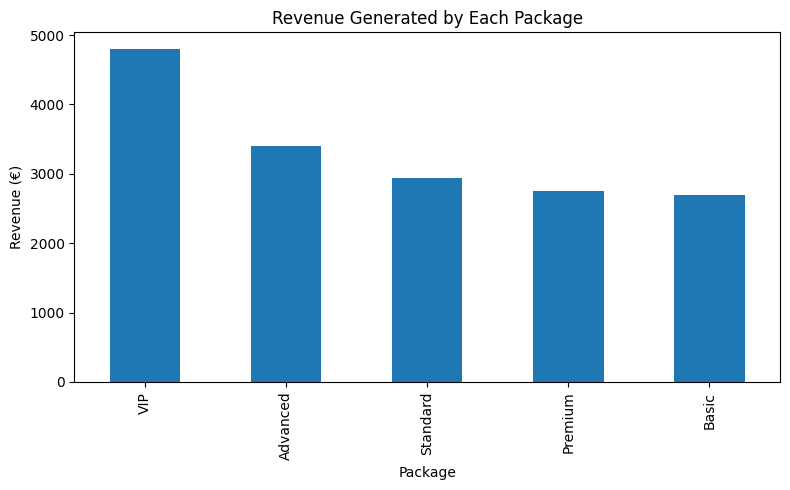

In [43]:
plt.figure(figsize=(8,5))

revenue_package.plot(kind="bar")

plt.title("Revenue Generated by Each Package")
plt.xlabel("Package")
plt.ylabel("Revenue (€)")

plt.tight_layout()
plt.show()

## Interpretation
The chart presents the total revenue generated by each training package offered by the driving school.
The VIP package generated the highest revenue, almost €5,000, making it the most profitable package. The Advanced package ranked second, while the Standard and Premium packages generated similar levels of revenue.
The basic package produced the lowest revenue among all available packages.
These results suggest that the VIP package is the most popular choice among students, contributing the largest share of the driving school's income.


# Part 6: Instructor Teaching Hours
This analysis evaluates the workload distribution among instructors.

In [45]:
instructor_hours = (
    lesson_full
    .groupby("InstructorName")["DurationHours"]
    .sum()
    .sort_values(ascending=False)
)

instructor_hours

InstructorName
Giulia Romano      51
Marco Rossi        48
Luca Bianchi       37
Andrea Conti       27
Francesca Ricci    26
Name: DurationHours, dtype: int64

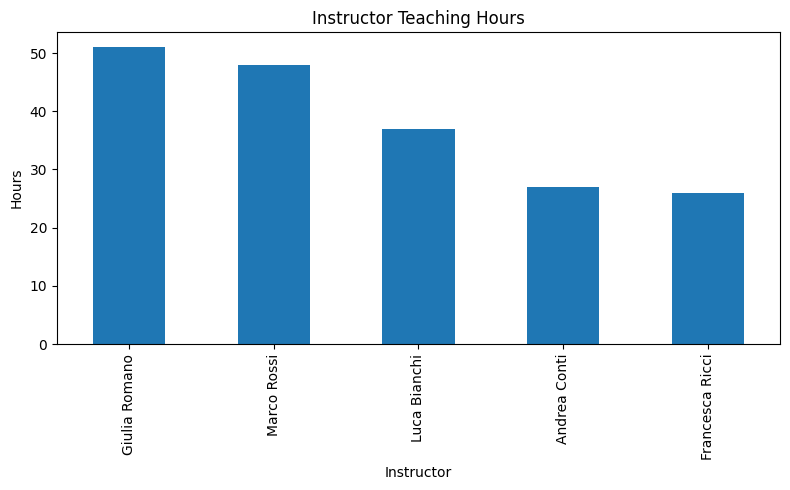

In [46]:
plt.figure(figsize=(8,5))

instructor_hours.plot(kind="bar")

plt.title("Instructor Teaching Hours")
plt.xlabel("Instructor")
plt.ylabel("Hours")

plt.tight_layout()
plt.show()

## Interpretation
The chart shows the total number of teaching hours delivered by each instructor.

Giulia Romano recorded the highest workload with approximately 51 teaching hours, followed closely by Marco Rossi with 48 hours. Luca Bianchi delivered a moderate number of hours, while Andrea Conti and Francesca Ricci had the lowest workloads, with approximately 27 and 26 hours respectively.

The results indicate that teaching responsibilities are not distributed equally among instructors. Giulia Romano and Marco Rossi appear to be the most active instructors in the driving school, conducting a significantly higher number of lesson hours than the others.

# Part 7: Exam Pass and Fail Statistics
This analysis examines student performance in driving examinations.

In [47]:
exam_stats = exams["Result"].value_counts()

exam_stats

Result
Passed    11
Failed     6
Name: count, dtype: int64

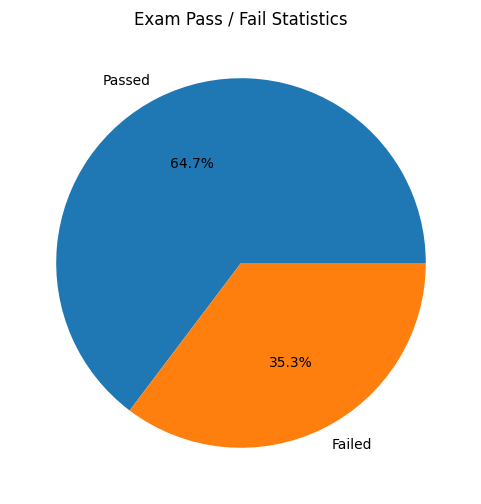

In [48]:
plt.figure(figsize=(6,6))

plt.pie(
    exam_stats,
    labels=exam_stats.index,
    autopct="%1.1f%%"
)

plt.title("Exam Pass / Fail Statistics")

plt.show()

## Interpretation
The pie chart illustrates the distribution of examination outcomes among students who took the driving test.
Approximately 64.7% of students passed the examination, while 35.3% failed. This indicates that nearly two-thirds of the students successfully met the requirements to obtain their driving license.

# Part 8: Vehicle Utilization
This analysis evaluates how frequently each vehicle is used during driving lessons.(Based on Hours)

In [53]:
vehicle_usage = (
    lesson_full
    .groupby("Model")["DurationHours"]
    .sum()
    .sort_values(ascending=False)
)

vehicle_usage

Model
Renault Clio       62
Toyota Yaris       49
Volkswagen Polo    40
Fiat Panda         38
Name: DurationHours, dtype: int64

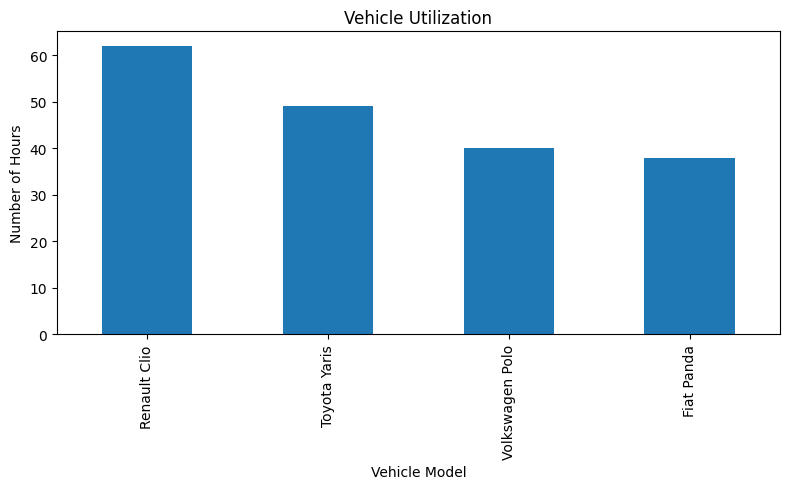

In [54]:
plt.figure(figsize=(8,5))

vehicle_usage.plot(kind="bar")

plt.title("Vehicle Utilization")
plt.xlabel("Vehicle Model")
plt.ylabel("Number of Hours")

plt.tight_layout()
plt.show()

## Interpretation

The chart illustrates the total number of driving hours completed by each training vehicle. The Renault Clio was the most utilized vehicle, accumulating approximately 62 driving hours, followed by the Toyota Yaris with around 49 hours. The Volkswagen Polo and Fiat Panda recorded lower utilization levels, with approximately 40 and 38 driving hours respectively.
The results indicate that the Renault Clio and Toyota Yaris play a more significant role in driving instruction activities, suggesting higher demand or greater availability compared to the other vehicles. Monitoring vehicle utilization is important for fleet management because it helps identify heavily used vehicles that may require more frequent maintenance and assists management in balancing lesson assignments across the fleet to improve operational efficiency

# Part 9: Package Effectiveness
This analysis investigates whether certain training packages achieve higher examination success rates.

In [57]:
package_exam = (
    student_packages
    .merge(exams, on="StudentID")
    .merge(packages, on="PackageID")
)

pass_rate = (
    package_exam
    .groupby("PackageName")["Result"]
    .apply(lambda x: (x == "Passed").mean() * 100)
    .sort_values(ascending=False)
)

pass_rate

PackageName
Premium     100.000000
Advanced     66.666667
VIP          66.666667
Basic        57.142857
Standard     50.000000
Name: Result, dtype: float64

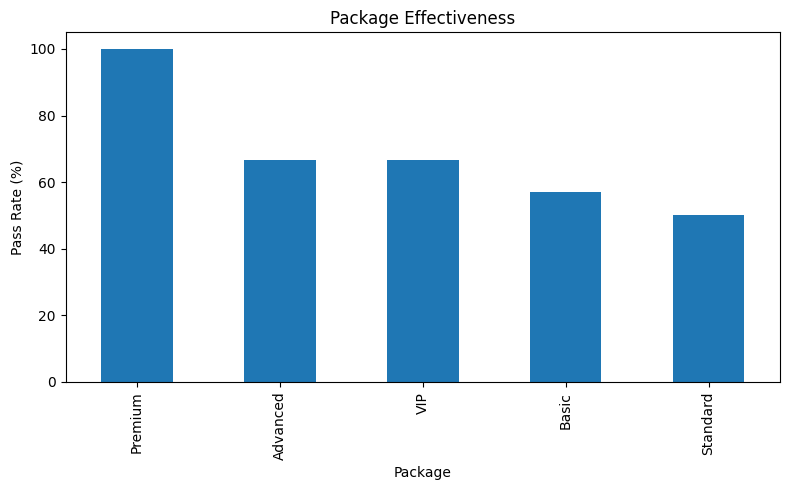

In [58]:
plt.figure(figsize=(8,5))

pass_rate.plot(kind="bar")

plt.title("Package Effectiveness")
plt.xlabel("Package")
plt.ylabel("Pass Rate (%)")

plt.tight_layout()
plt.show()

## Interpretation
The chart presents the examination pass rate associated with each training package.
The Premium package achieved the highest success rate, with 100% of students passing the examination. The Advanced and VIP packages also performed well, each achieving a pass rate of approximately 66.7%.
The Basic package achieved a pass rate of approximately 57%, while the Standard package recorded the lowest success rate at 50%.


# Conclusion

This project successfully demonstrated the design, implementation, and analysis of a Driving School Management System using MySQL and Python.

The database was developed to manage students, instructors, vehicles, lessons, examinations, payments, and training packages. Data was extracted from MySQL into Python using Pandas, cleaned and integrated, and then analyzed through a series of visualizations.

The analysis revealed several important findings:

- The Basic package generated the highest revenue and represented the primary source of income for the driving school.
- Instructor workloads were not evenly distributed, with some instructors conducting significantly more teaching hours than others.
- The overall examination pass rate was approximately 65%, indicating generally successful student preparation.
- Vehicle utilization was relatively balanced across the available fleet, supporting efficient resource allocation.
- Premium training packages achieved higher examination success rates, suggesting a positive relationship between training intensity and student performance.

Overall, the results demonstrate how database systems and data analysis techniques can provide valuable insights for decision-making within a driving school. The combination of SQL, Python, Pandas, and Matplotlib enabled the transformation of operational data into meaningful business information that can support planning, resource management, and service improvement.